In [17]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from ipywidgets import interact, IntSlider
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
import statsmodels.stats.diagnostic as dg

In [2]:
df = pd.read_csv("master.csv")
df["Date"] = pd.to_datetime(df["Date"], utc=True)
df.head()

,Date,log_return,mkt_return,tsla_volume,mkt_volume,tsla_wiki_views,tsla_edits,tsla_unique_editors,msk_wiki_views,msk_edits,msk_unique_editors,msk_tweets
0,2017-02-06 05:00:00+00:00,0.025301,-0.002118,53437500,3112390000,2224,2.0,2.0,25707,1.0,1.0,14.0
1,2017-02-07 05:00:00+00:00,-0.001126,0.000227,63672000,3452460000,2476,0.0,0.0,27886,0.0,0.0,1.0
2,2017-02-08 05:00:00+00:00,0.017708,0.000693,58995000,3611950000,3432,0.0,0.0,24202,3.0,2.0,5.0
3,2017-02-09 05:00:00+00:00,0.026805,0.005736,117303000,3681600000,4009,1.0,1.0,22390,1.0,1.0,5.0
4,2017-02-10 05:00:00+00:00,0.000111,0.003560,54295500,3496600000,3767,0.0,0.0,20018,2.0,2.0,1.0


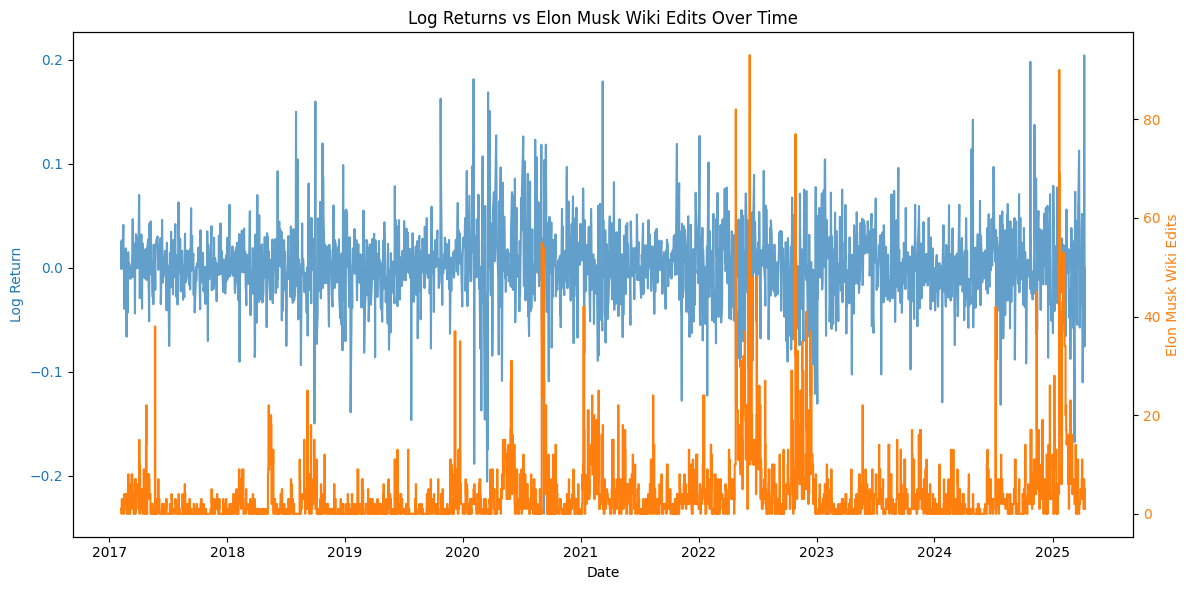

In [3]:
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Log Return', color=color)
ax1.plot(df['Date'], df['log_return'], color=color, label='Log Return', alpha=0.7)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx() 
color = 'tab:orange'
ax2.set_ylabel('Elon Musk Wiki Edits', color=color)
ax2.step(df['Date'], df['msk_edits'], color=color, label='Musk Edits', where='post')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Log Returns vs Elon Musk Wiki Edits Over Time')
fig.tight_layout()
plt.show()

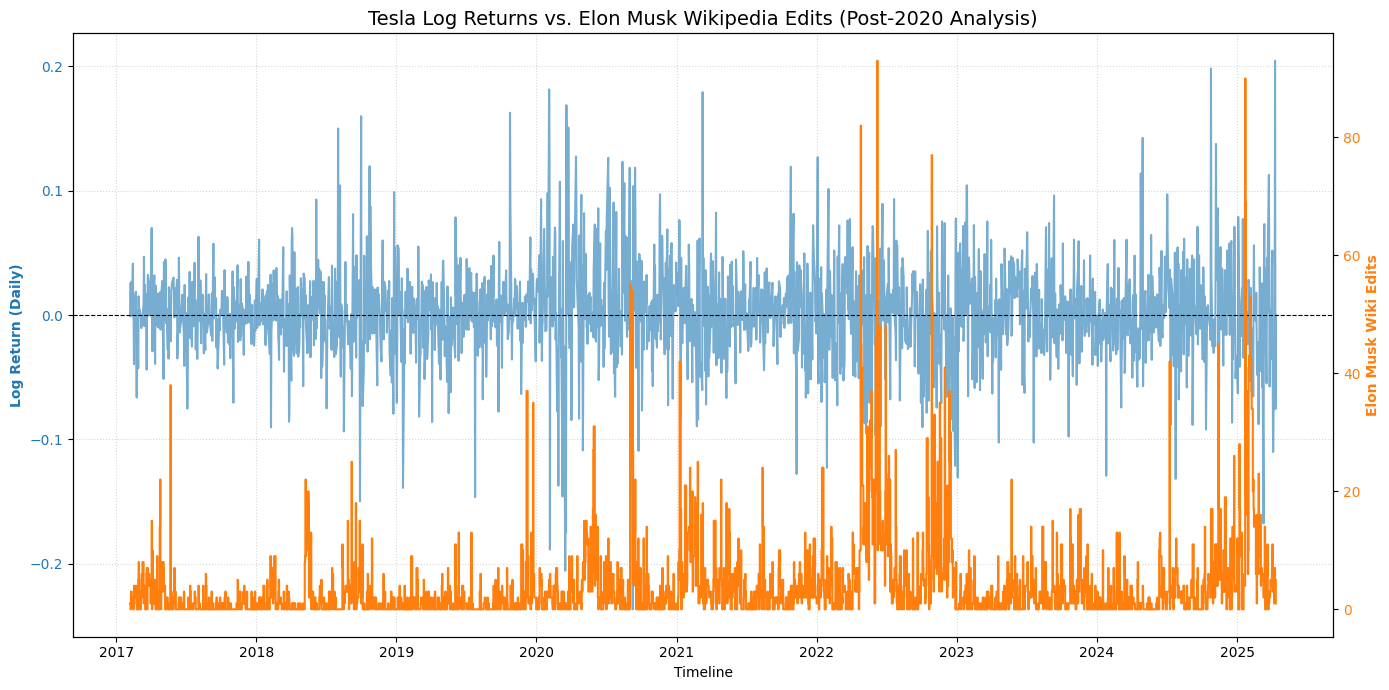

In [4]:
df['Date'] = pd.to_datetime(df['Date'])

df_filtered = df.copy()

fig, ax1 = plt.subplots(figsize=(14, 7))

color_return = 'tab:blue'
ax1.set_xlabel('Timeline')
ax1.set_ylabel('Log Return (Daily)', color=color_return, fontweight='bold')
ax1.plot(df_filtered['Date'], df_filtered['log_return'], color=color_return, alpha=0.6, label='Log Return')
ax1.tick_params(axis='y', labelcolor=color_return)

ax2 = ax1.twinx()

color_edits = 'tab:orange'
ax2.set_ylabel('Elon Musk Wiki Edits', color=color_edits, fontweight='bold')
ax2.step(df_filtered['Date'], df_filtered['msk_edits'], color=color_edits, where='post', label='Musk Edits')
ax2.tick_params(axis='y', labelcolor=color_edits)

ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.title('Tesla Log Returns vs. Elon Musk Wikipedia Edits (Post-2020 Analysis)', fontsize=14)
fig.tight_layout()

ax1.grid(True, which='both', linestyle=':', alpha=0.5)

plt.show()

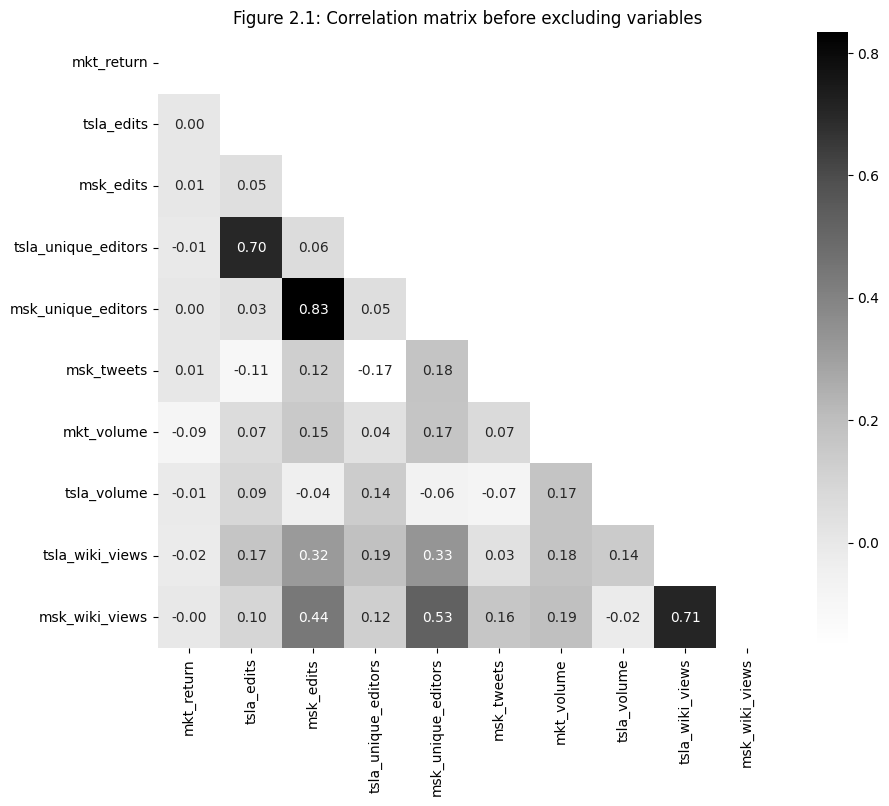

In [13]:
# Figure 2.1
cols_21 = [
    'mkt_return', 'tsla_edits', 'msk_edits', 'tsla_unique_editors', 
    'msk_unique_editors', 'msk_tweets', 'mkt_volume', 'tsla_volume', 
    'tsla_wiki_views', 'msk_wiki_views'
]
corr_21 = df[cols_21].corr()
mask_21 = np.triu(np.ones_like(corr_21, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_21, mask=mask_21, annot=True, fmt=".2f", cmap='Greys', cbar=True)
plt.title("Figure 2.1: Correlation matrix before excluding variables")
plt.show()



In [14]:
X = sm.add_constant(df['msk_wiki_views'])
y = df['tsla_wiki_views']

model = sm.OLS(y, X).fit()

df['tsla_views_unex'] = model.resid

print(df[['tsla_wiki_views', 'msk_wiki_views', 'tsla_views_unex']].head())

   tsla_wiki_views  msk_wiki_views  tsla_views_unex
0             2224           25707     -5549.909767
1             2476           27886     -5392.617384
2             3432           24202     -4276.496749
3             4009           22390     -3620.740346
4             3767           20018     -3759.644215


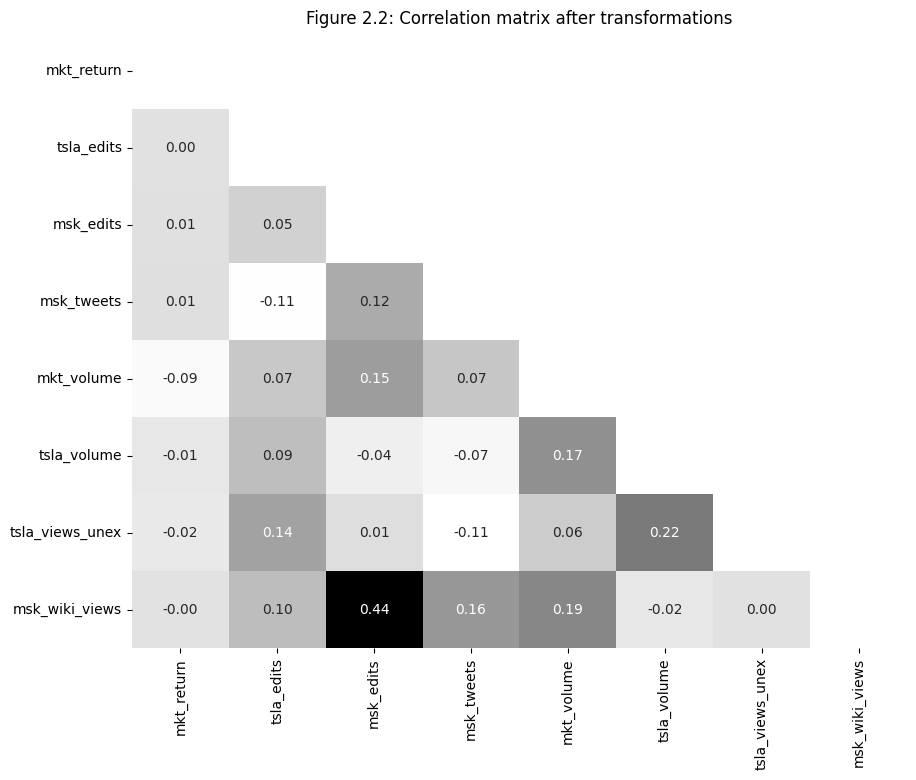

In [15]:
# Figure 2.2
cols_22 = [
    'mkt_return', 'tsla_edits', 'msk_edits', 'msk_tweets', 
    'mkt_volume', 'tsla_volume', 'tsla_views_unex', 'msk_wiki_views'
]
corr_22 = df[cols_22].corr()
mask_22 = np.triu(np.ones_like(corr_22, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_22, mask=mask_22, annot=True, fmt=".2f", cmap='Greys', cbar=False)
plt.title("Figure 2.2: Correlation matrix after transformations")
plt.show()

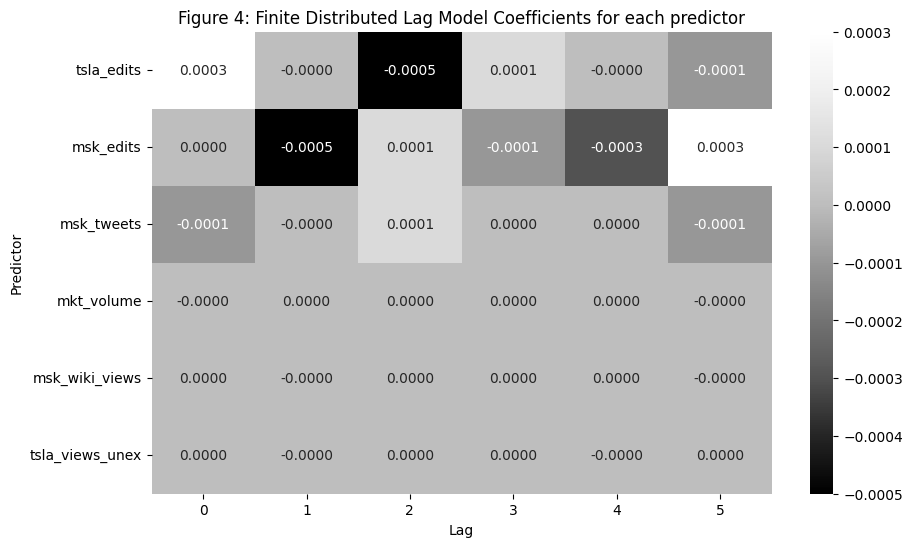

In [16]:
predictors = [
    'tsla_edits', 'msk_edits', 'msk_tweets', 
    'mkt_volume', 'msk_wiki_views', 'tsla_views_unex'
]

data = np.array([
    [0.0003, -0.0000, -0.0005, 0.0001, -0.0000, -0.0001],
    [0.0000, -0.0005, 0.0001, -0.0001, -0.0003, 0.0003],
    [-0.0001, -0.0000, 0.0001, 0.0000, 0.0000, -0.0001],
    [-0.0000, 0.0000, 0.0000, 0.0000, 0.0000, -0.0000],
    [0.0000, -0.0000, 0.0000, 0.0000, 0.0000, -0.0000],
    [0.0000, -0.0000, 0.0000, 0.0000, -0.0000, 0.0000]
])

df_hm = pd.DataFrame(data, index=predictors, columns=range(6))

plt.figure(figsize=(10, 6))
sns.heatmap(df_hm, annot=True, fmt=".4f", cmap='Greys_r', cbar=True)
plt.xlabel('Lag')
plt.ylabel('Predictor')
plt.title('Figure 4: Finite Distributed Lag Model Coefficients for each predictor')
plt.show()

In [ ]:
df['msk_edits_lag1'] = df['msk_edits'].shift(1)
df['log_tsla_volume'] = np.log(df['tsla_volume'] + 1)
df['log_mkt_volume'] = np.log(df['mkt_volume'] + 1)

In [19]:
df_clean = df.dropna(subset=[
    'log_return', 'mkt_return', 'log_mkt_volume', 'log_tsla_volume',
    'tsla_edits', 'tsla_views_unex', 'msk_tweets', 'msk_edits', 
    'msk_edits_lag1', 'msk_wiki_views'
])

X_cols = [
    'mkt_return', 'log_mkt_volume', 'log_tsla_volume', 'tsla_edits',
    'tsla_views_unex', 'msk_tweets', 'msk_edits', 'msk_edits_lag1', 
    'msk_wiki_views'
]

X = sm.add_constant(df_clean[X_cols])
y = df_clean['log_return']

model = sm.OLS(y, X).fit(cov_type='HC1')

bp_stat, bp_pval, f_stat, f_pval = dg.het_breuschpagan(model.resid, model.model.exog)
lb_test = dg.acorr_ljungbox(model.resid, lags=[10], return_df=True)

print(f"\nBreusch-Pagan: LM={bp_stat:.4f} (p={bp_pval:.4e}), F={f_stat:.4f} (p={f_pval:.4e})")
print("\nLjung-Box (10 lags):")
print(lb_test)


Breusch-Pagan: LM=395.6529 (p=1.1591e-79), F=54.1663 (p=1.0458e-88)

Ljung-Box (10 lags):
      lb_stat  lb_pvalue
10  10.173121   0.425438


In [20]:
formula = "log_return ~ mkt_return + log_tsla_volume + log_mkt_volume + tsla_edits + tsla_views_unex + msk_tweets + msk_edits + msk_edits_lag1 + msk_wiki_views"

def regress(a: int):
    dfc = df[df["Date"].dt.year >= a].copy()
    
    dfc = dfc.dropna(subset=['msk_edits_lag1'])

    lm = smf.ols(formula, data=dfc).fit(cov_type='HC1')
    
    print(f"====== Results for year >= {a} =====")
    print(lm.summary())

interact(regress, a=IntSlider(min=2017, max=2025, step=1, value=2017))

interactive(children=(IntSlider(value=2017, description='a', max=2025, min=2017), Output()), _dom_classes=('wi…

<function __main__.regress(a: int)>

In [22]:
formula = "log_return ~ mkt_return + log_tsla_volume + log_mkt_volume + tsla_edits + tsla_views_unex + msk_tweets + msk_edits + msk_edits_lag1 + msk_wiki_views"
dfc = df[df["Date"].dt.year >= 2020].copy()
dfc = dfc.dropna(subset=['msk_edits_lag1'])
lm = smf.ols(formula, data=dfc).fit(cov_type='HC1')

In [24]:
hypothesis_rq0 = 'msk_edits + msk_edits_lag1 = 0'
wald_test_rq0 = lm.wald_test(hypothesis_rq0, use_f=False)

print("RQ0 Wald t-test:")
print(wald_test_rq0)

z_stat = np.sqrt(wald_test_rq0.statistic.item())
p_val = wald_test_rq0.pvalue
print(f"z-statistic: {z_stat:.4f}")
print(f"p-value: {p_val:.4f}")

hypotheses_rq1 = '(msk_edits = 0), (msk_edits_lag1 = 0), (msk_wiki_views = 0)'
f_test_rq1 = lm.f_test(hypotheses_rq1)
print("RQ1 F-test:")
print(f_test_rq1)

dfc['msk_wiki_views_lag1'] = dfc['msk_wiki_views'].shift(1)
formula_rq2 = formula + " + msk_wiki_views_lag1"
lm_rq2 = smf.ols(formula_rq2, data=dfc.dropna()).fit(cov_type='HC1')

hypotheses_rq2 = 'msk_edits + msk_edits_lag1 = msk_wiki_views + msk_wiki_views_lag1'
t_test_rq2 = lm_rq2.wald_test(hypotheses_rq2, use_f=False)
print("\nRQ2 Wald test:")
print(t_test_rq2)

dfc['tsla_edits_lag1'] = dfc['tsla_edits'].shift(1)
formula_rq3 = formula + " + tsla_edits_lag1"
lm_rq3 = smf.ols(formula_rq3, data=dfc.dropna()).fit(cov_type='HC1')

hypotheses_rq3 = 'tsla_edits + tsla_views_unex + tsla_edits_lag1 = msk_edits + msk_edits_lag1 + msk_wiki_views'
t_test_rq3 = lm_rq3.wald_test(hypotheses_rq3, use_f=False)
print("\nRQ3 Wald test:")
print(t_test_rq3)

RQ0 Wald t-test:
<Wald test (chi2): statistic=[[6.06208217]], p-value=0.013811474941551926, df_denom=1>
z-statistic: 2.4621
p-value: 0.0138
RQ1 F-test:
<F test: F=2.9709977347197722, p=0.030840884191407666, df_denom=1.32e+03, df_num=3>

RQ2 Wald test:
<Wald test (chi2): statistic=[[5.9806447]], p-value=0.014463714162335285, df_denom=1>

RQ3 Wald test:
<Wald test (chi2): statistic=[[1.2384418]], p-value=0.26577156823990034, df_denom=1>


c:\python313\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
c:\python313\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


In [10]:
df['mkt_volume'].min(), df['mkt_volume'].max()

(np.int64(0), np.int64(9976520000))